In [1]:
# ── Cell 0: Setup (chạy đầu tiên) ──
import os

# Clone repo nếu chưa có
if not os.path.exists('/content/project'):
    !git clone https://github.com/TruongDuyLongPTIT/CTQW_PRO_METABOLITES_PRIORITIZING.git /content/project

# Add src vào Python path
import sys
sys.path.insert(0, '/content/project/src')

# Install dependencies nếu cần
!pip install -q torch scikit-learn networkx tqdm

Cloning into '/content/project'...
remote: Enumerating objects: 46, done.
remote: Counting objects: 100% (46/46), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 46 (delta 17), reused 17 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (46/46), 48.72 KiB | 831.00 KiB/s, done.
Resolving deltas: 100% (17/17), done.


In [2]:
from pathlib import Path
from google.colab import drive

if not Path('/content/drive/MyDrive').exists():
    drive.mount('/content/drive')
else:
    print("Drive đã mount sẵn.")

Mounted at /content/drive


In [3]:
!python /content/project/experiments/01_main_results.py

STEP 1 — Build graph
  Graph: 2788 nodes, 22439 edges
  G_pro: 2894 nodes (106 pathway), 31360 edges

STEP 2 — Build eval sets
  hmdb_to_recon: +0 IK, +331 name → 3286 total
  Extracting SMPDB metabolites...
  Disease pathways: 20248
SMPDB files: 100% 48687/48687 [00:34<00:00, 1421.89it/s]
  Loaded 20244 pathways (errors=0)
  Dedup: 20244 → 3240 → 362 → 215
  eval_set1 (HMDB+CTD): 158 diseases
  eval_set2 (MarkerDB): 21 diseases
  eval_set3 (SMPDB):    153 diseases

STEP 3 — Eigendecomposition
  Done.

  Device: cpu

[Table 1] RWR vs CTQW on G_cc...
RWR/HMDB+CTD: 100% 158/158 [11:45<00:00,  4.47s/it]
CTQW/HMDB+CTD: 100% 158/158 [07:52<00:00,  2.99s/it]
  HMDB+CTD: 19.6 min
RWR/MarkerDB: 100% 21/21 [02:28<00:00,  7.09s/it]
CTQW/MarkerDB: 100% 21/21 [01:31<00:00,  4.34s/it]
  MarkerDB: 4.0 min
RWR/SMPDB: 100% 153/153 [09:07<00:00,  3.58s/it]
CTQW/SMPDB: 100% 153/153 [05:39<00:00,  2.22s/it]
  SMPDB: 14.8 min

[Table 2] PROFANCY vs CTQW-PRO on G_pro...
PROFANCY/HMDB+CTD: 100% 158/158 [10:

In [4]:
!python /content/project/experiments/02_ablation_graph.py

Building graphs...
  G_pro: 2894 → clean: 2851 nodes
Building eval sets...
  Disease pathways: 20248
SMPDB files: 100% 48687/48687 [00:41<00:00, 1180.37it/s]
  Loaded 20244 pathways (errors=0)
  Dedup: 20244 → 3240 → 362 → 215
Eigendecomposition...

Running ablation...
PROF_o/HMDB+CTD: 100% 158/158 [11:32<00:00,  4.38s/it]
CTQW_o/HMDB+CTD: 100% 158/158 [08:03<00:00,  3.06s/it]
PROF_c/HMDB+CTD: 100% 158/158 [14:56<00:00,  5.68s/it]
CTQW_c/HMDB+CTD: 100% 158/158 [09:16<00:00,  3.52s/it]
  HMDB+CTD: 43.8 min
PROF_o/MarkerDB: 100% 21/21 [01:52<00:00,  5.37s/it]
CTQW_o/MarkerDB: 100% 21/21 [01:27<00:00,  4.17s/it]
PROF_c/MarkerDB: 100% 21/21 [03:02<00:00,  8.70s/it]
CTQW_c/MarkerDB: 100% 21/21 [01:40<00:00,  4.78s/it]
  MarkerDB: 8.1 min
PROF_o/SMPDB: 100% 153/153 [07:39<00:00,  3.01s/it]
CTQW_o/SMPDB: 100% 153/153 [06:00<00:00,  2.35s/it]
PROF_c/SMPDB: 100% 153/153 [11:46<00:00,  4.62s/it]
CTQW_c/SMPDB: 100% 153/153 [07:10<00:00,  2.81s/it]
  SMPDB: 32.6 min

ABLATION: Original vs Clean G_

In [5]:
!python /content/project/experiments/03_negative_results.py

Setup...
  Disease pathways: 20248
SMPDB files: 100% 48687/48687 [00:34<00:00, 1428.77it/s]
  Loaded 20244 pathways (errors=0)
  Dedup: 20244 → 3240 → 362 → 215
  SMPDB: 153 diseases
  Device: cpu

EXP 1: Chiral Quantum Walk
  Directed edges: 11099/31360 (35.4%)
Chiral φ=0: 100% 153/153 [01:06<00:00,  2.30it/s]
Chiral φ=π/8: 100% 153/153 [01:09<00:00,  2.19it/s]
Chiral φ=π/4: 100% 153/153 [01:01<00:00,  2.49it/s]
Chiral φ=π/3: 100% 153/153 [01:04<00:00,  2.38it/s]
Chiral φ=π/2: 100% 153/153 [01:06<00:00,  2.31it/s]

  φ           AUC      MRR    R@20
  ----------------------------
  0        0.9568   0.2172  0.5429
  π/8      0.9462   0.1858  0.5095
  π/4      0.9444   0.1624  0.4762
  π/3      0.9337   0.1367  0.4280
  π/2      0.9289   0.1740  0.4807
  Conclusion: Chiral walk does NOT improve — graph not sufficiently directed.

EXP 2: Geometric t schedule
Geometric-t: 100% 153/153 [07:36<00:00,  2.98s/it]
  Geometric-t: 7.6 min

  Method                      MRR     R@20
  ----------

In [ ]:
!apt-get install -y texlive-xetex texlive-fonts-recommended \
    texlive-plain-generic cm-super dvipng 2>/dev/null

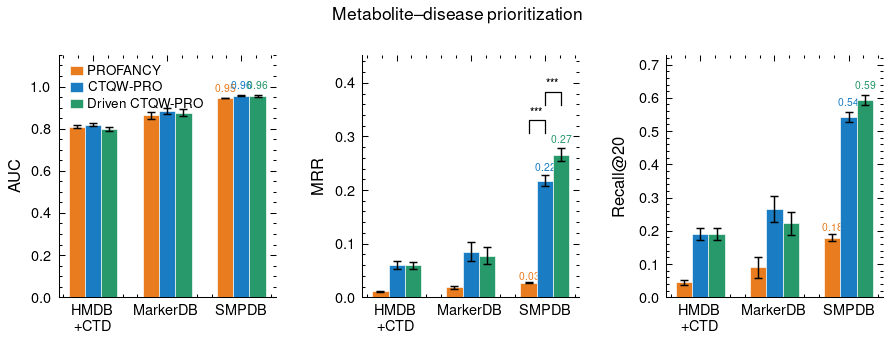

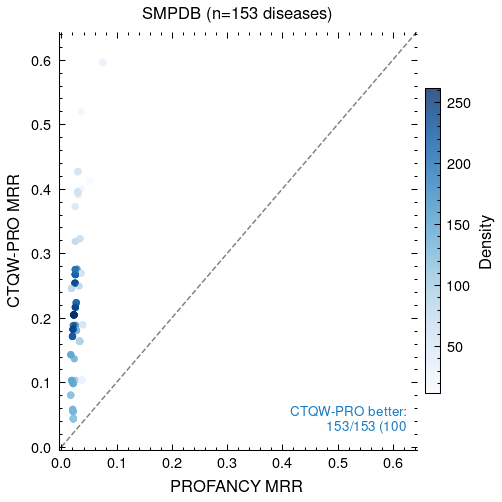

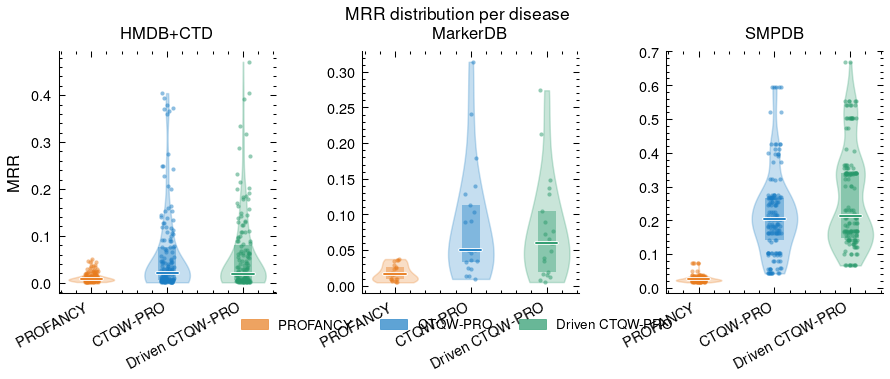

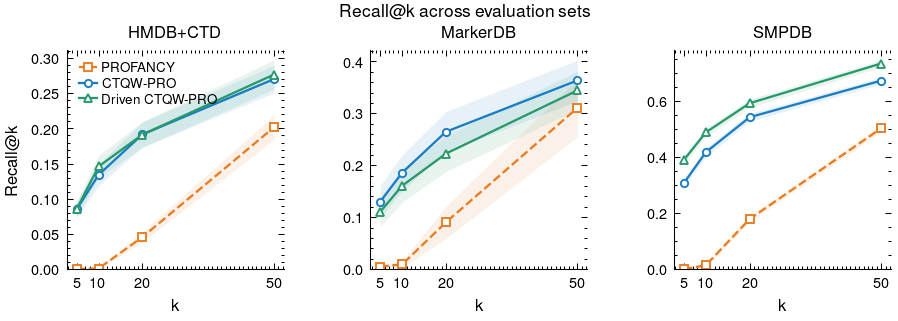


✓ Saved to: /content/drive/MyDrive/CTQW for metabolites/results/figures


In [20]:
# ════════════════════════════════════════════════════════════════
# CELL FIGURES — SciencePlots Nature style
# ════════════════════════════════════════════════════════════════
%matplotlib inline
import subprocess
subprocess.run(['pip','install','-q','SciencePlots'], capture_output=True)

import sys
sys.path.insert(0, '/content/project/src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scienceplots
import warnings; warnings.filterwarnings('ignore')
from config import RESULTS_DIR

plt.style.use(['science', 'nature'])

# Override một số thứ để phù hợp hơn với Colab display
plt.rcParams.update({
    'figure.dpi':    150,
    'savefig.dpi':   300,
    'font.size':     7,
    'axes.labelsize':8,
    'axes.titlesize':8,
    'legend.fontsize':6.5,
    'xtick.labelsize':7,
    'ytick.labelsize':7,
})

FIGS_DIR = RESULTS_DIR / 'figures'
FIGS_DIR.mkdir(parents=True, exist_ok=True)

def savefig(fig, name):
    for ext in ('pdf', 'png'):
        fig.savefig(FIGS_DIR / f'{name}.{ext}', dpi=300, bbox_inches='tight')

# ── Data helpers ──────────────────────────────────────────────
df_all = pd.read_csv(RESULTS_DIR / 'main_results.csv')
df_wx  = pd.read_csv(RESULTS_DIR / 'wilcoxon_results.csv') \
         if (RESULTS_DIR / 'wilcoxon_results.csv').exists() else None

TABLE_MAP = {'PROFANCY':'table2','t=0.1':'table2',
             'driven_s2_a0.5':'table3','RWR':'table1','CTQW':'table1'}

def gdf(method, source):
    tbl = TABLE_MAP.get(method,'table2')
    return df_all[(df_all['table']==tbl)&(df_all['method']==method)
                  &(df_all['source']==source)]

def gmean(m, s, k):
    d = gdf(m, s); return float(d[k].mean()) if not d.empty else np.nan

def gse(m, s, k):
    d = gdf(m, s); return float(d[k].sem()) if len(d)>1 else 0.0

def get_p(source, metric, row_idx=0):
    if df_wx is None: return np.nan
    r = df_wx[(df_wx['source']==source)&(df_wx['metric']==metric)]
    return float(r['p_bonf'].values[row_idx]) if len(r)>row_idx else np.nan

def sig(p):
    if np.isnan(p): return ''
    return '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'

def sig_bracket(ax, x1, x2, y, h, text, fs=5.5):
    ax.plot([x1,x1,x2,x2],[y,y+h,y+h,y], lw=0.6, c='k')
    ax.text((x1+x2)/2, y+h*1.1, text, ha='center', va='bottom',
            fontsize=fs, color='k')

SETS  = ['HMDB+CTD','MarkerDB','SMPDB']
MKEYS = ['PROFANCY','t=0.1','driven_s2_a0.5']
MLBLS = ['PROFANCY','CTQW-PRO','Driven CTQW-PRO']
# SciencePlots Nature palette — cycle picks these automatically
MCOLS = ['#E87C1E','#1A7DC4','#28996B']

# ════════════════════════════════════════════════════════════════
# FIG 1 — Grouped bar (AUC / MRR / Recall@20)
# ════════════════════════════════════════════════════════════════
METS = [('auc','AUC'), ('mrr','MRR'), ('r@20','Recall@20')]
fig, axes = plt.subplots(1, 3, figsize=(7.09, 2.1),
                          gridspec_kw={'wspace':0.40})

for ax, (met, lbl) in zip(axes, METS):
    x = np.arange(len(SETS)); w = 0.22
    offsets = np.array([-w, 0, w])
    ymax_g  = 0

    for j, (mk, ml, col) in enumerate(zip(MKEYS, MLBLS, MCOLS)):
        vals = np.array([gmean(mk, s, met) for s in SETS])
        errs = np.array([gse(mk, s, met) for s in SETS])
        vp, ep = np.nan_to_num(vals), np.nan_to_num(errs)
        ax.bar(x+offsets[j], vp, w, color=col, label=ml,
               edgecolor='white', linewidth=0.3, zorder=3)
        ax.errorbar(x+offsets[j], vp, yerr=ep, fmt='none',
                    ecolor='k', elinewidth=0.7, capsize=1.8,
                    capthick=0.7, zorder=4)
        ymax_g = max(ymax_g, (vp+ep).max())

        # Value label on SMPDB
        for xi, (v, e) in enumerate(zip(vp, ep)):
            if xi == 2 and v > 0.01:
                ax.text(xi+offsets[j], v+e+ymax_g*0.02,
                        f'{v:.2f}', ha='center', va='bottom',
                        fontsize=5, color=col, fontweight='bold')

    if met == 'mrr':
        vp_s = gmean('PROFANCY','SMPDB',met)
        vc_s = gmean('t=0.1','SMPDB',met)
        vd_s = gmean('driven_s2_a0.5','SMPDB',met)
        top = max(vp_s, vc_s, vd_s)
        ax.set_ylim(0, top*1.70)
        p1 = get_p('SMPDB','mrr',0)
        sig_bracket(ax, x[2]+offsets[0], x[2]+offsets[1],
                    top*1.15, top*0.09, sig(p1))
        if df_wx is not None:
            r = df_wx[(df_wx['source']=='SMPDB')&(df_wx['metric']=='mrr')]
            if len(r)>1:
                sig_bracket(ax, x[2]+offsets[1], x[2]+offsets[2],
                            top*1.35, top*0.09, sig(float(r['p_bonf'].values[1])))
    else:
        ax.set_ylim(0, ymax_g*1.20)

    ax.set_ylabel(lbl)
    ax.set_xticks(x)
    ax.set_xticklabels(['HMDB\n+CTD','MarkerDB','SMPDB'])

axes[0].legend(loc='upper left', handlelength=1.0,
               handletextpad=0.4, labelspacing=0.3, borderpad=0.3)
fig.suptitle('Metabolite–disease prioritization', y=1.03)
plt.show(); savefig(fig,'sp_fig1_bar')

# ════════════════════════════════════════════════════════════════
# FIG 2 — Per-disease scatter PROFANCY vs CTQW-PRO (SMPDB)
# ════════════════════════════════════════════════════════════════
from scipy.stats import gaussian_kde

dfp = gdf('PROFANCY','SMPDB').set_index('disease')
dfc = gdf('t=0.1',  'SMPDB').set_index('disease')
shared = sorted(set(dfp.index)&set(dfc.index))
mp  = dfp.loc[shared,'mrr'].values
mc  = dfc.loc[shared,'mrr'].values
delta = mc - mp

fig, ax = plt.subplots(figsize=(3.46, 3.46))

# Density-based coloring
xy   = np.vstack([mp, mc])
try:
    z = gaussian_kde(xy)(xy)
    sc = ax.scatter(mp, mc, c=z, cmap='Blues', s=12,
                    alpha=0.8, linewidths=0, zorder=3)
    plt.colorbar(sc, ax=ax, label='Density', shrink=0.8,
                 pad=0.02, fraction=0.04)
except Exception:
    ax.scatter(mp, mc, s=12, alpha=0.7, zorder=3)

lim = max(mp.max(), mc.max())*1.08
ax.plot([0,lim],[0,lim],'--k', lw=0.7, alpha=0.5, zorder=2)
ax.set_xlim(-0.005,lim); ax.set_ylim(-0.005,lim)
ax.set_xlabel('PROFANCY  MRR')
ax.set_ylabel('CTQW-PRO  MRR')
n_win = (delta>0).sum()
ax.text(0.97,0.04,
        f'CTQW-PRO better:\n{n_win}/{len(shared)} ({100*n_win/len(shared):.0f}%)',
        ha='right', va='bottom', transform=ax.transAxes,
        fontsize=6.5, color=MCOLS[1])
ax.set_title(f'SMPDB  (n={len(shared)} diseases)')
plt.tight_layout(); plt.show(); savefig(fig,'sp_fig2_scatter')

# ════════════════════════════════════════════════════════════════
# FIG 3 — Violin + strip
# ════════════════════════════════════════════════════════════════
rng = np.random.default_rng(42)
fig, axes = plt.subplots(1,3, figsize=(7.09,2.1),
                          gridspec_kw={'wspace':0.40})

for ax, src in zip(axes, SETS):
    data_list = [gdf(mk,src)['mrr'].values for mk in MKEYS]
    data_ok   = [(d,l,c) for d,l,c in zip(data_list,MLBLS,MCOLS) if len(d)>1]
    if not data_ok: continue

    parts = ax.violinplot([d for d,_,_ in data_ok],
                          positions=range(len(data_ok)),
                          showmedians=False, showextrema=False, widths=0.6)
    for body,(_,_,c) in zip(parts['bodies'],data_ok):
        body.set_facecolor(c); body.set_alpha(0.25)
        body.set_edgecolor(c); body.set_linewidth(0.7)

    for i,(d,_,c) in enumerate(data_ok):
        q25,med,q75 = np.percentile(d,[25,50,75])
        ax.fill_between([i-0.12,i+0.12],[q25,q25],[q75,q75],
                        color=c, alpha=0.4, linewidth=0, zorder=3)
        ax.plot([i-0.14,i+0.14],[med,med], lw=1.8, c='w',
                solid_capstyle='round', zorder=4)
        ax.plot([i-0.14,i+0.14],[med,med], lw=0.9, c=c,
                solid_capstyle='round', zorder=5)
        jitter = rng.uniform(-0.09,0.09,len(d))
        ax.scatter(i+jitter, d, s=4, color=c, alpha=0.5,
                   linewidths=0, zorder=2)

    ax.set_xticks(range(len(data_ok)))
    ax.set_xticklabels([l for _,l,_ in data_ok],
                        rotation=28, ha='right')
    ax.set_ylabel('MRR' if src=='HMDB+CTD' else '')
    ax.set_title(src)

handles = [mpatches.Patch(color=c,label=l,alpha=0.7)
           for l,c in zip(MLBLS,MCOLS)]
fig.legend(handles=handles, loc='lower center', ncol=3,
           frameon=False, bbox_to_anchor=(0.5,-0.05))
fig.suptitle('MRR distribution per disease', y=1.02)
plt.tight_layout(); plt.show(); savefig(fig,'sp_fig3_violin')

# ════════════════════════════════════════════════════════════════
# FIG 4 — Recall@k curves + SE shading
# ════════════════════════════════════════════════════════════════
K_VALS  = [5,10,20,50]
MSTYLES = [('PROFANCY','PROFANCY',MCOLS[0],'--','s'),
           ('t=0.1','CTQW-PRO',MCOLS[1],'-','o'),
           ('driven_s2_a0.5','Driven CTQW-PRO',MCOLS[2],'-','^')]

fig, axes = plt.subplots(1,3, figsize=(7.09,1.9),
                          gridspec_kw={'wspace':0.40})

for ax, src in zip(axes, SETS):
    for mk,ml,col,ls,mk_ in MSTYLES:
        d = gdf(mk, src)
        if d.empty: continue
        means = np.array([float(d[f'r@{k}'].mean()) for k in K_VALS])
        sems  = np.array([float(d[f'r@{k}'].sem())  for k in K_VALS])
        ax.plot(K_VALS, means, ls, color=col, markersize=3.5,
                marker=mk_, label=ml, linewidth=1.1,
                markerfacecolor='w', markeredgewidth=0.9)
        ax.fill_between(K_VALS, means-sems, means+sems,
                        color=col, alpha=0.10, linewidth=0)
    ax.set_xlabel('k')
    ax.set_ylabel('Recall@k' if src=='HMDB+CTD' else '')
    ax.set_title(src)
    ax.set_xticks(K_VALS)
    ax.set_ylim(bottom=0)

axes[0].legend(loc='upper left', handlelength=1.3,
               handletextpad=0.4, labelspacing=0.25)
fig.suptitle('Recall@k across evaluation sets', y=1.03)
plt.tight_layout(); plt.show(); savefig(fig,'sp_fig4_recall')

print(f'\n✓ Saved to: {FIGS_DIR}')